In [1]:
pip install pycaret

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


2025-05-06 09:38:58.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:38:58.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:38:58.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:38:58.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:38:58.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:38:58.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:38:58.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:38:58.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1338, 7)"
4,Transformed data shape,"(1338, 10)"
5,Transformed train set shape,"(936, 10)"
6,Transformed test set shape,"(402, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


Transformation Pipeline and Model Successfully Loaded


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,2219.8743,15663377.0613,3957.6985,0.8931,0.3650,0.2634


2025-05-06 09:39:00.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:39:00.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:39:00.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:39:00.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:39:00.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:39:00.936 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:39:00.936 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-06 09:39:00.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

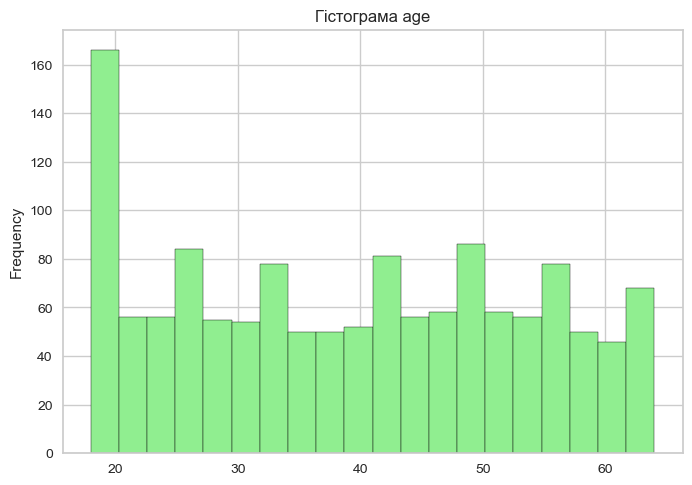

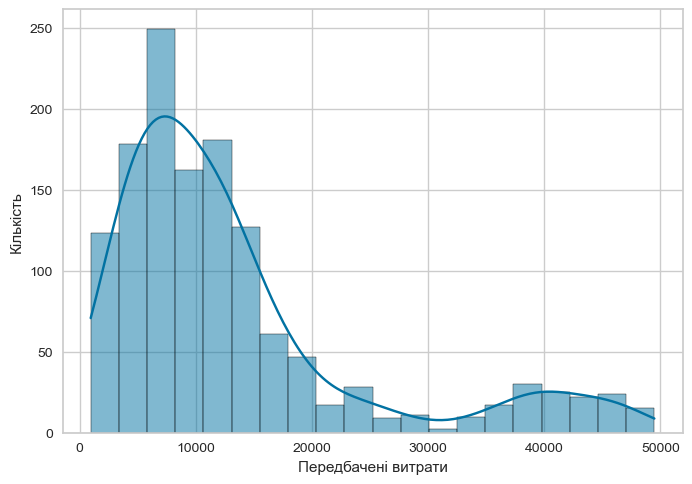

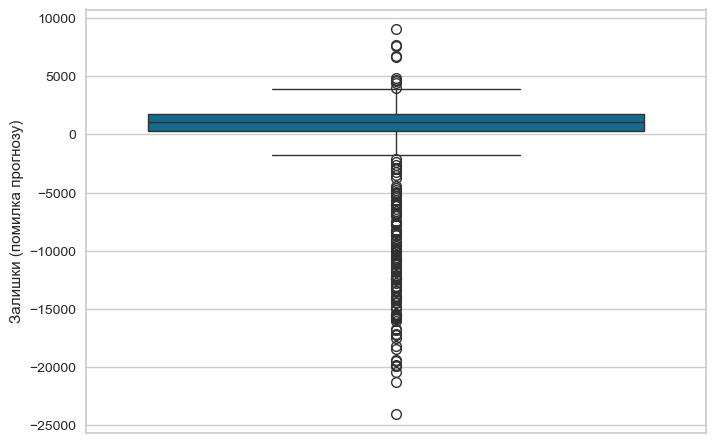

In [11]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.datasets import get_data
from pycaret.regression import setup, load_model, predict_model

# Завантаження даних
data = get_data('insurance')

# Опис ознак
st.title("Аналіз датасету Insurance")

st.write("### Опис ознак:")
feature_description = {
    "age": "Вік клієнта (років)",
    "sex": "Стать клієнта (male / female)",
    "bmi": "Індекс маси тіла (kg/m²)",
    "children": "Кількість дітей у клієнта",
    "smoker": "Чи є клієнт курцем (yes / no)",
    "region": "Регіон проживання (northeast, northwest, southeast, southwest)",
    "charges": "Витрати на медичне страхування (долари)"
}

st.table(pd.DataFrame(list(feature_description.items()), columns=["Ознака", "Опис"]))

# Інтерактивна візуалізація
st.write("### Візуалізація даних")
selected_feature = st.selectbox("Оберіть ознаку для відображення", data.columns)

fig, ax = plt.subplots()

if data[selected_feature].dtype == 'object':
    data[selected_feature].value_counts().plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f'Розподіл {selected_feature}')
else:
    data[selected_feature].plot(kind='hist', bins=20, ax=ax, color='lightgreen', edgecolor='black')
    ax.set_title(f'Гістограма {selected_feature}')

st.pyplot(fig)

st.write("### Описова статистика")
st.write(data.describe())

# Завантаження моделі та передбачення
st.header("Результати моделі")
regression_setup = setup(data=data, target='charges', session_id=123)
model = load_model('insurance_model')
predictions = predict_model(model, data=data)

# Вивід метрик
st.write("Перші передбачення:")
st.write(predictions.head())

# Розподіл ймовірностей
st.subheader("Розподіл передбачень")
fig, ax = plt.subplots()
sns.histplot(predictions['prediction_label'], bins=20, kde=True, ax=ax)
ax.set_xlabel("Передбачені витрати")
ax.set_ylabel("Кількість")
st.pyplot(fig)

# Boxplot залишків
st.subheader("Boxplot залишків")
fig, ax = plt.subplots()
residuals = predictions['prediction_label'] - predictions['charges']
sns.boxplot(y=residuals, ax=ax)
ax.set_ylabel("Залишки (помилка прогнозу)")
st.pyplot(fig)